# Interpretable ML on Life Satisfaction in the EU 🇪🇺: a tutorial using the trust-free package

### Licensing 📜

The content of this project — including the dataset, tutorial text, and code — is made available under the following open licenses:

* **Dataset:** Licensed under **Creative Commons Attribution 4.0 (CC BY 4.0)**.
* **Tutorial Text:** Licensed under **Creative Commons Attribution 4.0 (CC BY 4.0)**.
* **Tutorial Code:** Licensed under the **MIT License**.

### Contact 📧
For questions, feedback, or to report any issues, please open an issue on the project's [GitHub page](https://github.com/adc-trust-ai/trust-free).

There will also be a link to a 2-minute feedback form at the end of this tutorial. *Your* input will shape future releases!

Feel free to connect with me on [LinkedIn](https://www.linkedin.com/in/albertdorador/) to stay up-to-date with our latest research and software developments on interpretable ML.

## Introduction 🚀

In this tutorial we will use real data from Eurostat (European Commission) and other sources to explore the capabilities of the new `trust-free` Python package for state-of-the-art interpretable regression analysis. Along the way, we will discover some of the variables with the strongest association with life satisfaction in the EU, and exactly *how* they relate depending on a few key factors.

Paraphrasing the famous quote from George Box, founder of [my alma mater's Statistics department](https://stat.wisc.edu/), "all models are wrong, but some are useful" our approach assumes that, while not perfect, the model is sufficiently close to the truth to provide meaningful insights. As we will see, this indeed appears to be the case.

We will begin by retrieving the data (with some optional wrangling steps), then analyze it with `trust-free`, which makes it easy to uncover new insights. **One of these insights may even have interesting policy-making implications for a large European economy!** Finally, we’ll compare results against popular machine learning models such as Random Forest, Decision Trees, and Lasso regression.

The very first step is to download and install the latest version of `trust-free`. In your terminal, run:

```bash
pip install trust-free
```

> **Note:** At present, `trust-free` ships with a precompiled binary and is tested only for **Python 3.11** on **macOS 11+** with **ARM64** architecture (e.g., M1/M2/M3/M4 chips). Support for Intel macOS, Linux, and Windows is planned for future releases. For reproducibility, at the very end of this tutorial you will find the exact session info.


### Reference paper

- Dorador, A. (2025). *TRUST: Transparent, Robust and Ultra-Sparse Trees*. [arXiv:2506.15791](https://arxiv.org/abs/2506.15791).


In [1]:
#Import essential modules
import pandas as pd
import numpy as np
from trust import TRUST

## 1. Data 📊

### 1.1. Overview

Our analysis builds on an extended version of Eurostat’s `ilc_pw02b` dataset (*Life satisfaction by income quintile, household composition, degree of urbanisation and domain*). After filtering (e.g., year = 2022), this dataset contains **2,062 records** and **3 original features** that are central to our study:

- **`deg_urb`** (degree of urbanisation): categorical with 3 levels  
  - DEG1 = big cities  
  - DEG2 = smaller cities  
  - DEG3 = rural areas  

- **`hhcomp`** (household composition): categorical with 5 levels  
  - DCH = household with dependent children  
  - A_GE3 = 3 or more adults  
  - NDCH = no dependent children  
  - A2 = 2 adults  
  - A1 = 1 adult  

- **`quant_inc`** (income quantiles): categorical with 5 levels  
  - QU1 = 1st quintile (bottom 20% of incomes in the country)  
  - QU2 = 2nd quintile ([20th–40th) income percentiles)  
  - QU3 = 3rd quintile ([40th–60th) income percentiles)  
  - QU4 = 4th quintile ([60th–80th) income percentiles)  
  - QU5 = 5th quintile (top 20% of incomes)  

An additional identifier variable (`geo\TIME_PERIOD`) encodes the country, but we treat it as auxiliary. This variable has 29 levels: the 27 current EU member states (excluding Germany), plus Switzerland and Norway (EFTA), and Serbia (EU candidate). Country-level features will be added later (e.g., sunlight).  

In practice, each row represents a *household type* within a given country. At most, each country has $3 \times 5 \times 5 = 75$ household types, though some combinations are missing.

---

We further enriched the dataset with **17 country-level features**, drawn from Eurostat and other reputable sources:

| Feature |  Code (Eurostat) | Source |
|---------|------------------|--------|
| Death rates from air pollution | `sdg_11_52` | [Eurostat](https://ec.europa.eu/eurostat) |
| Corruption perception | `sdg_16_50` | [Eurostat](https://ec.europa.eu/eurostat) |
| Perceived crime | `ilc_mddw03` | [Eurostat](https://ec.europa.eu/eurostat) |
| Divorce rates | `tps00216` | [Eurostat](https://ec.europa.eu/eurostat) |
| Donation rates | – | [World Happiness Report](https://www.worldhappiness.report/data-sharing/) |
| Environmental Policy Stringency Index | – | [OECD](https://data-explorer.oecd.org/vis?tenant=archive&df[ds]=DisseminateArchiveDMZ&df[id]=DF_EPS&df[ag]=OECD&dq=.&lom=LASTNPERIODS&lo=5&to[TIME_PERIOD]=false) |
| Fertility rates | `tps00199` | [Eurostat](https://ec.europa.eu/eurostat) |
| Income inequality | `tessi190` | [Eurostat](https://ec.europa.eu/eurostat) |
| Green areas in cities | – | [United Nations](https://data.unhabitat.org/pages/open-spaces-and-green-areas) |
| Human Development Index | – | [United Nations](https://hdr.undp.org/data-center/human-development-index#/indicies/HDI) |
| Inflation | `prc_hicp_aind` | [Eurostat](https://ec.europa.eu/eurostat) |
| Housing costs | `ilc_lvho07a` | [Eurostat](https://ec.europa.eu/eurostat) |
| Sunlight | – | [Wikipedia](https://en.wikipedia.org/wiki/List_of_cities_in_Europe_by_sunshine_duration) |
| Social support rate | `ilc_pw06` | [Eurostat](https://ec.europa.eu/eurostat) |
| Tourism density | `tour_occ_ninat` | [Eurostat](https://ec.europa.eu/eurostat) |
| Unemployment | `une_rt_a` | [Eurostat](https://ec.europa.eu/eurostat) |
| Gender equality | `sdg_05_50` | [Eurostat](https://ec.europa.eu/eurostat) |
 

Because the precise timing of the 2022 life satisfaction survey is uncertain, we averaged feature values across 2021–2022 (when available) to improve robustness.

---

The **target variable** is life satisfaction (`LifeSat`) at the household-type level. It is computed as the mean of three sub-scores:  

- **TIME** = satisfaction with time use  
- **FIN** = satisfaction with financial situation  
- **PER_RELS** = satisfaction with personal relationships  

To ensure reproducibility, the complete dataset is available on the project’s [GitHub page](https://github.com/adc-trust-ai/trust-free/blob/main/notebooks/LifeSatData.csv).

For transparency, we also document how to retrieve the individual source datasets and replicate the preprocessing steps. You may, however, skip these details and jump ahead to Section [2. Analysis](#2.-Analysis-🔬).

### 1.2. Retrieval and Wrangling

In [2]:
# Step 1: Get datasets

import eurostat

# 0. Eurostat dataset on life satisfaction (target variable + 3 demographic features)
df_LS = eurostat.get_data_df('ilc_pw02b').rename(columns={'geo\\TIME_PERIOD': 'Country', '2022': 'LifeSat'})
df_LS = df_LS.iloc[:,[1,3,4,5,7,10]].dropna(subset=["LifeSat"])
df_LS = df_LS[df_LS['deg_urb'] != 'TOTAL'] #keep it broken down by degree of urbanization
df_LS = df_LS[df_LS['hhcomp'] != 'TOTAL'] #keep it broken down by household composition
df_LS = df_LS[df_LS['quant_inc'] != 'TOTAL'] #keep it broken down by income quintile
df_LS = df_LS[~df_LS['Country'].isin(["EU27_2020", "EA20"])] #keep actual countries only
# Let's combine the 3 aspects of life satisfaction ('TIME', 'FIN', 'PER_RELS') into one
grouping_columns = ['deg_urb', 'hhcomp', 'quant_inc', 'Country']
df_LS = df_LS.groupby(grouping_columns)['LifeSat'].mean().reset_index()

# 1. Eurostat data on death rates by exposure to fine particulate matter (PM2.5) as a proxy for concentration of air pollutants
df_AQ = eurostat.get_data_df('sdg_11_52').rename(columns={'geo\\TIME_PERIOD': 'Country'})
df_AQ = df_AQ[df_AQ['unit'] == 'RT'] #keep rate only, not raw quantities
df_AQ = df_AQ.iloc[:,[4,-2,-1]]
df_AQ['AirPoll_Deaths'] = df_AQ.iloc[:, 1:3].mean(axis=1)
df_AQ = df_AQ.iloc[:, [0, -1]]

# 2. Corruption perception (Eurostat)
df_Corrupt = eurostat.get_data_df('sdg_16_50').rename(columns={'geo\\TIME_PERIOD': 'Country','2021': 'Honesty_2021','2022': 'Honesty_2022'})
df_Corrupt = df_Corrupt.iloc[:,[2,-4,-3]]
df_Corrupt['Honesty'] = df_Corrupt.iloc[:, 1:3].mean(axis=1)
df_Corrupt = df_Corrupt.iloc[:, [0, -1]]

# 3. Perceived crime (Eurostat)
# % who report crime, violence or vandalism in the area is a problem
df_Crim = eurostat.get_data_df('ilc_mddw03').rename(columns={'geo\\TIME_PERIOD': 'Country', '2020': 'Crim_2020', '2023': 'Crim_2023'})
df_Crim = df_Crim[df_Crim['hhtyp'] == 'TOTAL'] #total figures
df_Crim = df_Crim[df_Crim['incgrp'] == 'TOTAL'] #total figures
df_Crim = df_Crim.iloc[:,[4,-2,-1]]
df_Crim['Crim'] = df_Crim.iloc[:, 1:3].mean(axis=1)
df_Crim = df_Crim.iloc[:, [0, -1]]

# 4. Divorce rates (Eurostat)
# Crude divorce rate (per 1,000 persons)
df_Div = eurostat.get_data_df('tps00216').rename(columns={'geo\\TIME_PERIOD': 'Country', '2021': 'Div_2021', '2022': 'Div_2022'})
df_Div = df_Div.iloc[:,[2,-3,-2]]
df_Div['DivorceRT'] = df_Div.iloc[:, 1:3].mean(axis=1)
df_Div = df_Div.iloc[:, [0, -1]]

# 5. Generosity (World Happiness Report)
# Year 2022, Statistical Appendix 1 for Chapter 2
# % Who Donated to Charity in the Past Month 2019-2021 average
Countries = df_LS["Country"].unique()
#print(Countries)
Donated = [0.485, 0.233, 0.306, 0.423, 0.345, 0.402, 0.479, 0.336, 0.132, 0.302,
0.331, 0.259, 0.295, 0.249, 0.518, 0.279, 0.223, 0.415, 0.242, 0.5, 0.62, 0.538,
0.331, 0.147, 0.179, 0.451, 0.524, 0.33, 0.316]
df_Donat = pd.DataFrame({'Country': Countries,'PercDonated': Donated})

# 6. OECD's Environmental Policy Stringency Index 
github_url = "https://raw.githubusercontent.com/adc-trust-ai/trust-free/refs/heads/main/notebooks/DF_EPS.csv"
df_EPS = pd.read_csv(github_url) #Environmental Policy Stringency Index
df_EPS = df_EPS.iloc[:, [5,10]].rename(columns={'OBS_VALUE': 'EPS'})
# I suspect EPS and mortality due to air pollutants may interact, so worth including both

# 7. Eurostat data on fertility rates, as proxy for societal optimism
df_Fert = eurostat.get_data_df('tps00199').rename(columns={'geo\\TIME_PERIOD': 'Country', '2021': 'Fert_2021', '2022': 'Fert_2022'})
df_Fert = df_Fert.iloc[:,[2,-3,-2]]
df_Fert['Fert'] = df_Fert.iloc[:, 1:3].mean(axis=1)
df_Fert = df_Fert.iloc[:, [0, -1]]

# 8. Income inequality (Eurostat)
# Gini coefficient of equivalised disposable income
df_Gini = eurostat.get_data_df('tessi190').rename(columns={'geo\\TIME_PERIOD': 'Country', '2021': 'Gini_2021', '2022': 'Gini_2022'})
df_Gini = df_Gini.iloc[:,[3,-4,-3]]
df_Gini['IncomeIneq'] = df_Gini.iloc[:, 1:3].mean(axis=1)
df_Gini = df_Gini.iloc[:, [0, -1]]

# 9. Green areas (UN)
github_url = "https://raw.githubusercontent.com/adc-trust-ai/trust-free/refs/heads/main/notebooks/Share_of_green_areas.xlsx"
df_Green = pd.read_excel(github_url, sheet_name=1).rename(columns={'Country or Territory Name': 'Country', 'Average share of green area in city/ urban area 2020 (%)': 'GreenArea'})
df_Green = df_Green.iloc[:,[0,8]]
grouping_columns = ['Country']
df_Green = df_Green.groupby(grouping_columns)['GreenArea'].mean().reset_index()

# 10. United Nations HDI index
url_hdi = "https://hdr.undp.org/sites/default/files/2025_HDR/HDR25_Statistical_Annex_HDI_Trends_Table.xlsx"
import requests
import io
response = requests.get(url_hdi)
df_HDI = pd.read_excel(io.BytesIO(response.content)) #needs openpyxl
df_HDI = df_HDI.iloc[5:105, [1,12,14]].rename(columns={'Table 2. Human Development Index trends, 1990-2023': 'Country','Unnamed: 12': 'HDI_2021', 'Unnamed: 14': 'HDI_2022'})
df_HDI = pd.DataFrame({
    df_HDI.columns[0]: df_HDI.iloc[:, 0],  # First column
    'HDI': df_HDI.iloc[:, 1:3].mean(axis=1)  # Average of second (2021) and third (2022) columns
})

# 11. Eurostat dataset on inflation (HICP)
df_HICP = eurostat.get_data_df('prc_hicp_aind').rename(columns={'geo\\TIME_PERIOD': 'Country', '2021': 'HICP_2021', '2022': 'HICP_2022'})
df_HICP = df_HICP[df_HICP['unit'] == 'RCH_A_AVG'] #keep annual avg rate of change
df_HICP = df_HICP[df_HICP['coicop'] == 'CP00'] #total figures
df_HICP = df_HICP.iloc[:,[1,2,3,-4,-3]]
df_HICP['Inflation'] = df_HICP.iloc[:, 3:5].mean(axis=1)
df_HICP = df_HICP.iloc[:, [0, 1, 2, -1]]

# 12. Housing cost overburden (Eurostat)
df_House = eurostat.get_data_df('ilc_lvho07a').rename(columns={'geo\\TIME_PERIOD': 'Country', '2021': 'House_2021', '2022': 'House_2022'})
df_House = df_House[df_House['incgrp'] == 'TOTAL'] #total figures
df_House = df_House[df_House['age'] == 'TOTAL'] #total figures
df_House = df_House[df_House['sex'] == 'T'] #total figures
df_House = df_House.iloc[:,[5,-4,-3]]
df_House['HouseCost'] = df_House.iloc[:, 1:3].mean(axis=1)
df_House = df_House.iloc[:, [0, -1]]

# 13. Data on sunlight hours in Europe (source: Wikipedia)
url_sun = "https://en.wikipedia.org/wiki/List_of_cities_in_Europe_by_sunshine_duration"
df_Sun = pd.read_html(url_sun)[0] #needs lxml
df_Sun = df_Sun.iloc[:, [0,-2]].rename(columns={'Year': 'Sun'})
grouping_columns = ['Country']
df_Sun = df_Sun.groupby(grouping_columns)['Sun'].mean().reset_index()

# 14. Social support rate (Eurostat)
# Persons having someone to rely on in case of need by sex, age and educational attainment
df_Support = eurostat.get_data_df('ilc_pw06').rename(columns={'geo\\TIME_PERIOD': 'Country', '2022': 'Support'})
df_Support = df_Support[df_Support['isced11'] == 'TOTAL'] #total figures
df_Support = df_Support[df_Support['sex'] == 'T'] #total figures
df_Support = df_Support[df_Support['age'] == 'Y_GE16'] #16 y.o. and up
df_Support = df_Support.iloc[:,[5,-1]]

# 15. Eurostat data on tourism density, as a proxy for country attractiveness... or massification!
df_Tour = eurostat.get_data_df('tour_occ_ninat').rename(columns={'geo\\TIME_PERIOD': 'Country', '2021': 'Tour_2021', '2022': 'Tour_2022'})
df_Tour = df_Tour[df_Tour['c_resid'] == 'TOTAL'] #total figures
df_Tour = df_Tour[df_Tour['unit'] == 'P_THAB'] #per thousand inhabitants
df_Tour = df_Tour.iloc[:,[4,-4,-3]]
df_Tour['TourDens'] = df_Tour.iloc[:, 1:3].mean(axis=1)
df_Tour = df_Tour.iloc[:, [0, -1]]

# 16. Eurostat dataset on unemployment
df_Unemp = eurostat.get_data_df('une_rt_a').rename(columns={'geo\\TIME_PERIOD': 'Country', '2021': 'Unemp_2021', '2022': 'Unemp_2022'})
df_Unemp = df_Unemp[df_Unemp['sex'] == 'T'] #total figures
df_Unemp = df_Unemp[df_Unemp['age'] == 'Y15-74'] #keep only widest range
df_Unemp = df_Unemp[df_Unemp['unit'] == 'PC_ACT'] #keep only % of active population
df_Unemp = df_Unemp.iloc[:,[1,2,3,4,-4,-3]]
df_Unemp['Unemp'] = df_Unemp.iloc[:, 4:6].mean(axis=1)
df_Unemp = df_Unemp.iloc[:, [0, 1, 2, 3, -1]]

# 17. Gender equality (Eurostat)
# Seats held by women in national parliaments and governments
df_Women = eurostat.get_data_df('sdg_05_50').rename(columns={'geo\\TIME_PERIOD': 'Country', '2021': 'Women_2021', '2022': 'Women_2022'})
df_Women = df_Women[df_Women['org_inst'] == 'PARL_NAT'] #keep only parliament figures
df_Women = df_Women.iloc[:,[4,-4,-3]]
df_Women['PercWomen'] = df_Women.iloc[:, 1:3].mean(axis=1)
df_Women = df_Women.iloc[:, [0, -1]]

# Step 2: Left join datasets on Country
# First unify Country names...

# A mapping from country codes to full names for European countries
#print(sorted(set(df_LS["Country"]))) # DE (Germany) not available for 2022!
country_map = {
    'AT': 'Austria',
    'BE': 'Belgium',
    'BG': 'Bulgaria',
    'CH': 'Switzerland',
    'CY': 'Cyprus',
    'CZ': 'Czechia',
    'DK': 'Denmark',
    'EE': 'Estonia',
    'EL': 'Greece',
    'ES': 'Spain',
    'FI': 'Finland',
    'FR': 'France',
    'HR': 'Croatia',
    'HU': 'Hungary',
    'IE': 'Ireland',
    'IT': 'Italy',
    'LT': 'Lithuania',
    'LU': 'Luxembourg',
    'LV': 'Latvia',
    'MT': 'Malta',
    'NL': 'Netherlands',
    'NO': 'Norway',
    'PL': 'Poland',
    'PT': 'Portugal',
    'RO': 'Romania',
    'RS': 'Serbia',
    'SE': 'Sweden',
    'SI': 'Slovenia',
    'SK': 'Slovakia'
}

# Standardize the 'Country' column in all Eurostat datasets using country_map
df_LS['Country'] = df_LS['Country'].replace(country_map)
df_LS = df_LS[~df_LS['Country'].isin(['EA20', 'EU27_2020'])]
df_AQ['Country'] = df_AQ['Country'].replace(country_map)
df_Corrupt['Country'] = df_Corrupt['Country'].replace(country_map)
df_Crim['Country'] = df_Crim['Country'].replace(country_map)
df_Div['Country'] = df_Div['Country'].replace(country_map)
df_Donat['Country'] = df_Donat['Country'].replace(country_map)
df_EPS.iloc[np.where(df_EPS['Country'] == 'Slovak Republic')[0],0]="Slovakia"
df_Fert['Country'] = df_Fert['Country'].replace(country_map)
df_Gini['Country'] = df_Gini['Country'].replace(country_map)
df_HICP['Country'] = df_HICP['Country'].replace(country_map)
df_HICP = df_HICP.iloc[:,[-2,-1]]
df_House['Country'] = df_House['Country'].replace(country_map)
df_Sun.iloc[np.where(df_Sun['Country'] == 'Czech Republic')[0],0]="Czechia"
df_Support['Country'] = df_Support['Country'].replace(country_map)
df_Tour['Country'] = df_Tour['Country'].replace(country_map)
df_Unemp['Country'] = df_Unemp['Country'].replace(country_map)
df_Unemp = df_Unemp.iloc[:,[-2,-1]]
df_Women['Country'] = df_Women['Country'].replace(country_map)

# Perform sequential left joins
df_complete = pd.merge(df_LS, df_AQ, on='Country', how='left')
df_complete = pd.merge(df_complete, df_Corrupt, on='Country', how='left')
df_complete = pd.merge(df_complete, df_Crim, on='Country', how='left')
df_complete = pd.merge(df_complete, df_Div, on='Country', how='left')
df_complete = pd.merge(df_complete, df_Donat, on='Country', how='left')
df_complete = pd.merge(df_complete, df_EPS, on='Country', how='left')
df_complete = pd.merge(df_complete, df_Fert, on='Country', how='left')
df_complete = pd.merge(df_complete, df_Gini, on='Country', how='left')
df_complete = pd.merge(df_complete, df_Green, on='Country', how='left')
df_complete = pd.merge(df_complete, df_HDI, on='Country', how='left')
df_complete = pd.merge(df_complete, df_HICP, on='Country', how='left')
df_complete = pd.merge(df_complete, df_House, on='Country', how='left')
df_complete = pd.merge(df_complete, df_Sun, on='Country', how='left')
df_complete = pd.merge(df_complete, df_Support, on='Country', how='left')
df_complete = pd.merge(df_complete, df_Tour, on='Country', how='left')
df_complete = pd.merge(df_complete, df_Unemp, on='Country', how='left')
df_complete = pd.merge(df_complete, df_Women, on='Country', how='left')

df_complete = df_complete.drop("Country", axis=1)

# Move target to last column
columns = df_complete.columns.tolist()
columns.pop(columns.index('LifeSat'))
columns.append('LifeSat')
df_complete = df_complete[columns]

# How many missing values?
print(df_complete.isnull().sum().sum()) #1280
# out of
print(df_complete.shape[0]*(df_complete.shape[1]-1)) #41240
# so only (1280/41240)*100 % i.e. about 3%, in 2062 rows and 20 columns

df_complete['HDI'] = pd.to_numeric(df_complete['HDI']) #for some reason it was of object type

1280
41240


## 2. Analysis 🔬

In this section we will analyze our dataset using the trust-free package.

In case you have skiped the steps in Section [1.2. Retrieval and Wrangling](#1.2.-Retrieval-and-Wrangling), you can download the complete dataset from the project's [GitHub page](https://github.com/adc-trust-ai/trust-free/blob/main/notebooks/LifeSatData.csv).

### 2.1. Model fitting with trust-free

In [3]:
# if you need to, you may download the complete dataset here:
#github_url = "https://raw.githubusercontent.com/adc-trust-ai/trust-free/refs/heads/main/notebooks/LifeSatData.csv"
#df_complete = pd.read_csv(github_url)

from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
from trust import TRUST
X = df_complete.iloc[:,:-1]
y = df_complete.iloc[:,-1]

# Make train (70%) - test (30%) split (I ALWAYS use the same seed in all my works)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=123)

# Instantiate and fit a TRUST tree with at most depth 2 (4 leaves)
model = TRUST(max_depth=2)
model.fit(X_train, y_train, catvar=[0,1,2], y_LB=0, y_UB=10) # should take about 10 secs

# Predict and examine results
y_pred = model.predict(X_test)
print("\nFirst 5 predictions:", np.round(y_pred[:5],3))
print("First 5 true y values in test set:", np.round(y_test.values[:5],3))
print("Test R^2:", round(r2_score(y_test, y_pred),3)) #0.845

***** TRUST: Transparent, Robust & Ultra-Sparse Trees [v1.1.1] *****
***** Copyright (c) 2025 Albert Dorador Chalar. All rights reserved. *****
Caution: 892 missing values (3.1%) will be median-imputed in the leaves (unless a categorical variable).
Missing value information by feature
                # missing  % missing
deg_urb                 0       0.00
hhcomp                  0       0.00
quant_inc               0       0.00
AirPoll_Deaths          0       0.00
Honesty                 0       0.00
Crim                    0       0.00
DivorceRT             242      16.77
PercDonated             0       0.00
EPS                   403      27.93
Fert                    0       0.00
IncomeIneq              0       0.00
GreenArea             191      13.24
HDI                     0       0.00
Inflation               0       0.00
HouseCost               0       0.00
Sun                     0       0.00
Support                 0       0.00
TourDens                0       0.00
Unemp      

As we will see later, a test $R^2$ of 0.845 is a remarkable achievement on par with a Random Forest having 500 trees and nearly half a million leaves.

For peace of mind, let's check this is a legitimate score by checking model assumptions are not violated. We assume the error term $\epsilon$ in $y = f(x) + \epsilon$ has zero mean, constant variance, and is independent and (approximately) normally distributed.

The code snippet below suggests that there are no glaring signs of any model violation. So far so good!

0.0285


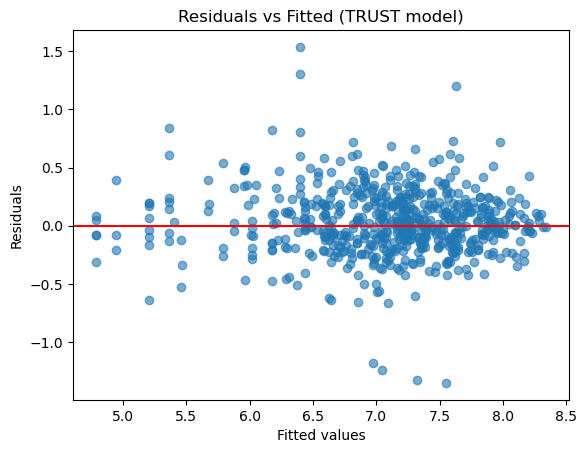

In [4]:
# Checking model assumptions are not violated
import matplotlib.pyplot as plt

residuals = y_test - y_pred
print(round(np.mean(residuals),4)) #close to 0

# Residuals vs fitted
# If we are to believe our prediction 'y_hat' matches f(x) under above assumptions, the residuals should be randomly scattered around zero,
# with no discernible pattern. If a pattern (e.g., a funnel shape, a curve) is observed, it suggests a violation of model assumptions.
plt.clf()
plt.scatter(y_pred, residuals, alpha=0.6)
plt.axhline(0, color="red")
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted (TRUST model)")
plt.show() # a few points have larger-than-ideal residues, but overall it looks pretty good to me!

### 2.2. Gaining insights with trust-free

Now that we have fitted a TRUST model with substantial accuracy and have no reason to believe assumption violations, let's dive right into the fun: exploring the *white box* to gain real insights into our model, and, by extension, into the drivers of life satisfaction in the EU.

The first thing we'd like to see is the tree structure learnt from our data.

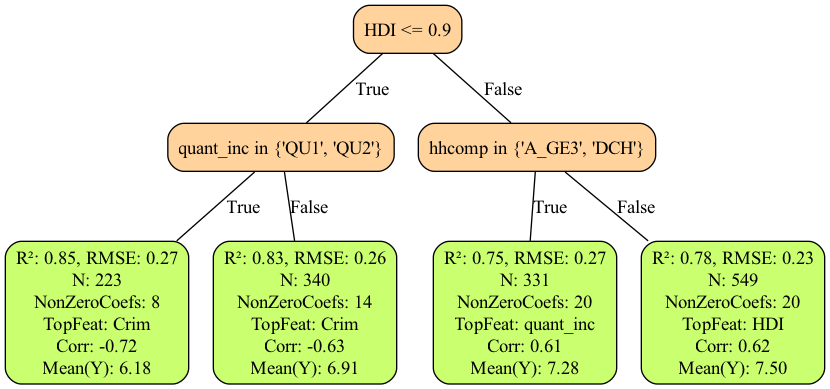

In [5]:
# (a) Plot the entire tree structure
model.plot_tree("LifeSat")

We see that the fitted tree is very small (as requested) with only 4 leaves, yet very accurate (test $R^2 = 0.845$).

The above tree structre that `trust-free` learnt from data reveals that there are **4 substantially different groups of households in Europe** depending on their country's HDI level as well as their individual income quantile and household composition. Therefore, a different linear model to predict life satisfaction is needed for each of them, as shown in the terminal nodes of the tree.

Let's now dive into some more substantial analysis.

For example, let's request a thorough explanation of the prediction corresponding to the 7th record in our test set, which corresponds to a lower-income (QU2) household with 3 or more adults (A_GE3) in a rural area (DEG3). Maybe we wish to have an explanation because the predicted life satisfaction feels rather small at only 5.88 out of 10, which is well below the EU average of 7.11.

As shown below, we can easily accomplish this with the `explain` method, which is unique to `trust-free`.

***** Selected Instance Prediction Explanation *****
Observed feature values (unstandardized):
deg_urb              DEG3
hhcomp              A_GE3
quant_inc             QU2
AirPoll_Deaths      189.0
Honesty              37.0
Crim                 9.15
DivorceRT            1.45
PercDonated          0.45
EPS                   NaN
Fert                 1.56
IncomeIneq          32.95
GreenArea           12.12
HDI                  0.82
Inflation            7.85
HouseCost            15.7
Sun                2055.0
Support              89.1
TourDens          1494.27
Unemp                10.4
PercWomen            38.1

Feature values after median imputation (and target-encoding):
deg_urb              DEG3
hhcomp              A_GE3
quant_inc             QU2
AirPoll_Deaths      189.0
Honesty              37.0
Crim                 9.15
DivorceRT            1.45
PercDonated          0.45
EPS                  3.44
Fert                 1.56
IncomeIneq          32.95
GreenArea           12.12
HDI       

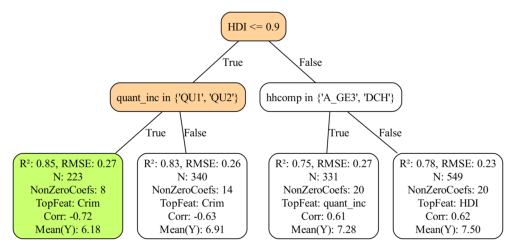


Showing destandardized regression coefficients
Estimated nonzero Relaxed Lasso coefficients:
                Estimate  Std. Error  t value       P(>|t|) Signif.
[Intercept]         5.51        0.83     6.62  2.860039e-10     ***
quant_inc           1.00        0.09    11.07  7.949981e-23     ***
AirPoll_Deaths     -0.00        0.00    -8.94  1.793551e-16     ***
Crim               -0.06        0.01   -11.20  3.362887e-23     ***
Fert               -1.33        0.19    -7.03  2.710646e-11     ***
Support            -0.03        0.00    -8.23  1.785204e-14     ***
TourDens           -0.00        0.00    -8.34  9.204927e-15     ***
Unemp              -0.06        0.01    -5.09  7.717232e-07     ***
PercWomen           0.01        0.00     2.53  1.217648e-02       *
*Note 1: Estimates are only approximately Gaussian in Relaxed Lasso regression.
*Note 2: p-values above not adjusted for variable selection, multiplicity or split search.
**Estimate for categorical variable quant_inc correspon

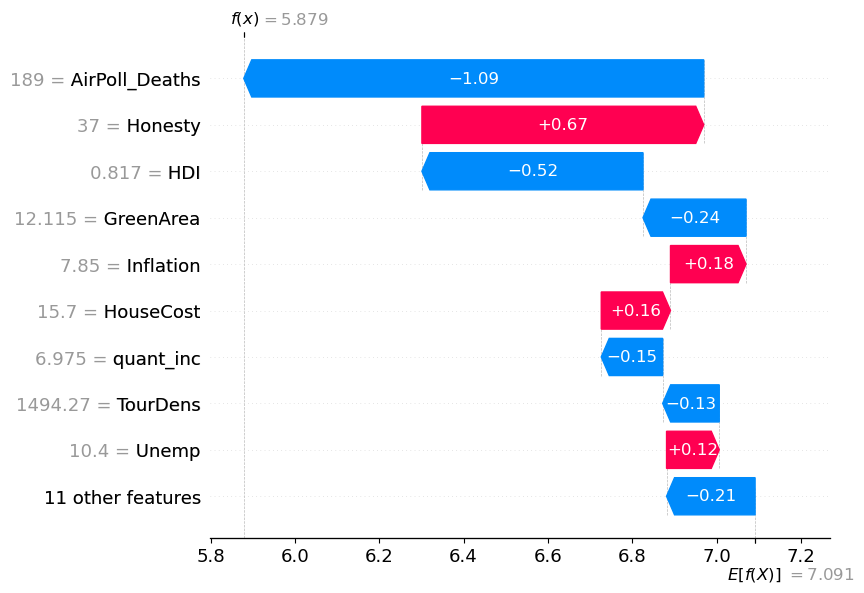

 prediction  avg pred.  AirPoll_Deaths  Honesty   HDI  GreenArea  Inflation  HouseCost  quant_inc  TourDens  Unemp  Others
       5.88       7.09           -1.09     0.67 -0.52      -0.24       0.18       0.16      -0.15     -0.13   0.12   -0.21

--- Terminal node metrics ---
RMSE: 0.27. Adj. R²: 0.85. F-stat: 157.5, p-value: 1.11e-16.
Actual LifeSat value: 5.83
Predicted LifeSat value: 5.88, difference: 0.78%
Average LifeSat value in leaf: 6.18, difference: 5.93%

<<< Summary >>>
-The predicted value of 5.88 (very small) is mainly due to quant_inc being QU2, a very large value of AirPoll_Deaths, intermediate values of Crim and Fert, a small value of Support, and a very small value of HDI. Note: although this configuration yielded a very small predicted value, it is not necessarily the only configuration capable of doing so.
-Compared to the training instance with largest predicted response, this instance has smaller Support, quant_inc QU2 instead of QU5, larger AirPoll_Deaths, larger 

In [6]:
# (b) Explain the prediction for e.g. the seventh instance in my test set:
# a lower-income (QU2) household with 3 or more adults (A_GE3) in a rural area (DEG3)
model.explain(X_test.iloc[6,:], y_pred[6], actual=y_test.values[6], filename="LifeSat")

Here are the key insights that we can extract for this instance:

- The prediction of **5.88**, while rather small, is in fact very close to the true value of **5.83**, and not that far off the average true value of similar instances (having `HDI` $\leq 0.9$ and `quant_inc` in the bottom 40\%).
- Only **8 out of 20 features** were found necessary to make an accurate prediction, which simplifies explanations substantially.
- Most features are associated with life satisfaction in the expected way. For instances having `HDI` $\leq 0.9$ and `quant_inc` in the bottom 40\%:

| Factor | Effect on Life Satisfaction |
|--------|------------------------------|
| Income (Q1 → Q2) | Improvement of **1 point** (on a 0–10 scale) |
| Air Quality ↓ | Expected decrease |
| Crime ↑ | Expected decrease |
| Unemployment ↑ | Expected decrease |

- However, there's one case that feels counterintuitive: larger values of social **`support`** are associated with *lower* life satisfaction values. This is not intuitive and would warrant further investigation, especially since it's highly statistically significant (*p-value* $=10^{-14}$).  
  👉 In a future pro version of **TRUST**, it will be possible to ask a state-of-the-art LLM about possible reasons why this is the case in this particular instance, given all the specific context available.

- The **SHAP analysis** reveals that the value of **air quality (189)** is the main driver behind this below-average predicted value. The second most impactful feature, in terms of deviating from the average prediction, is actually **honesty (37)**, which has an estimated coefficient of 0 (!) in our leaf.  
  ⚡ This paradoxical behavior is possible: a coefficient may be shrunk to zero due to regularization, but SHAP could still assign some attribution if the feature is correlated with retained ones.

---

Now that we know exactly how the predicted value of 5.88 came about, it's time to zoom out and gain some further global understanding of the model by checking the **variable importance scores**.  

> It must be stressed that these are the importance scores for *this model*, which does not mean they are the same ones as in *'nature'* (assuming there's a unique regression model for this task in nature).

To gauge the overall importance *for our model* of each feature, we use the **Ghost variable method** (Delicado and Pena, 2023), which is fast and corrects an important issue with the popular permutation-based approaches—namely, their ignorance of correlation among features.  

This method, just like all the other popular importance scoring methods, does not automatically inform about the *direction* of this importance, i.e. whether a feature is mostly positively or negatively associated with the target.  

👉 To get this information we turn to **Accumulated Local Effects (ALE) plots**, which show how the prediction changes as you change the value of each feature, accounting for correlations among features.  

Lastly, an optional **correlation analysis** is also included, which reveals which features would become more or less strongly associated with the target if they were considered in isolation.

***** Ghost Guide Variable Importance Scoring *****
                # missing  % missing
deg_urb                 0       0.00
hhcomp                  0       0.00
quant_inc               0       0.00
AirPoll_Deaths          0       0.00
Honesty                 0       0.00
Crim                    0       0.00
DivorceRT             242      16.77
PercDonated             0       0.00
EPS                   403      27.93
Fert                    0       0.00
IncomeIneq              0       0.00
GreenArea             191      13.24
HDI                     0       0.00
Inflation               0       0.00
HouseCost               0       0.00
Sun                     0       0.00
Support                 0       0.00
TourDens                0       0.00
Unemp                   0       0.00
PercWomen              56       3.88
ALE plots cannot handle missing values natively, and so, to allow plotting:
-Numeric variables are median-imputed
Note: this step may introduce distortions.



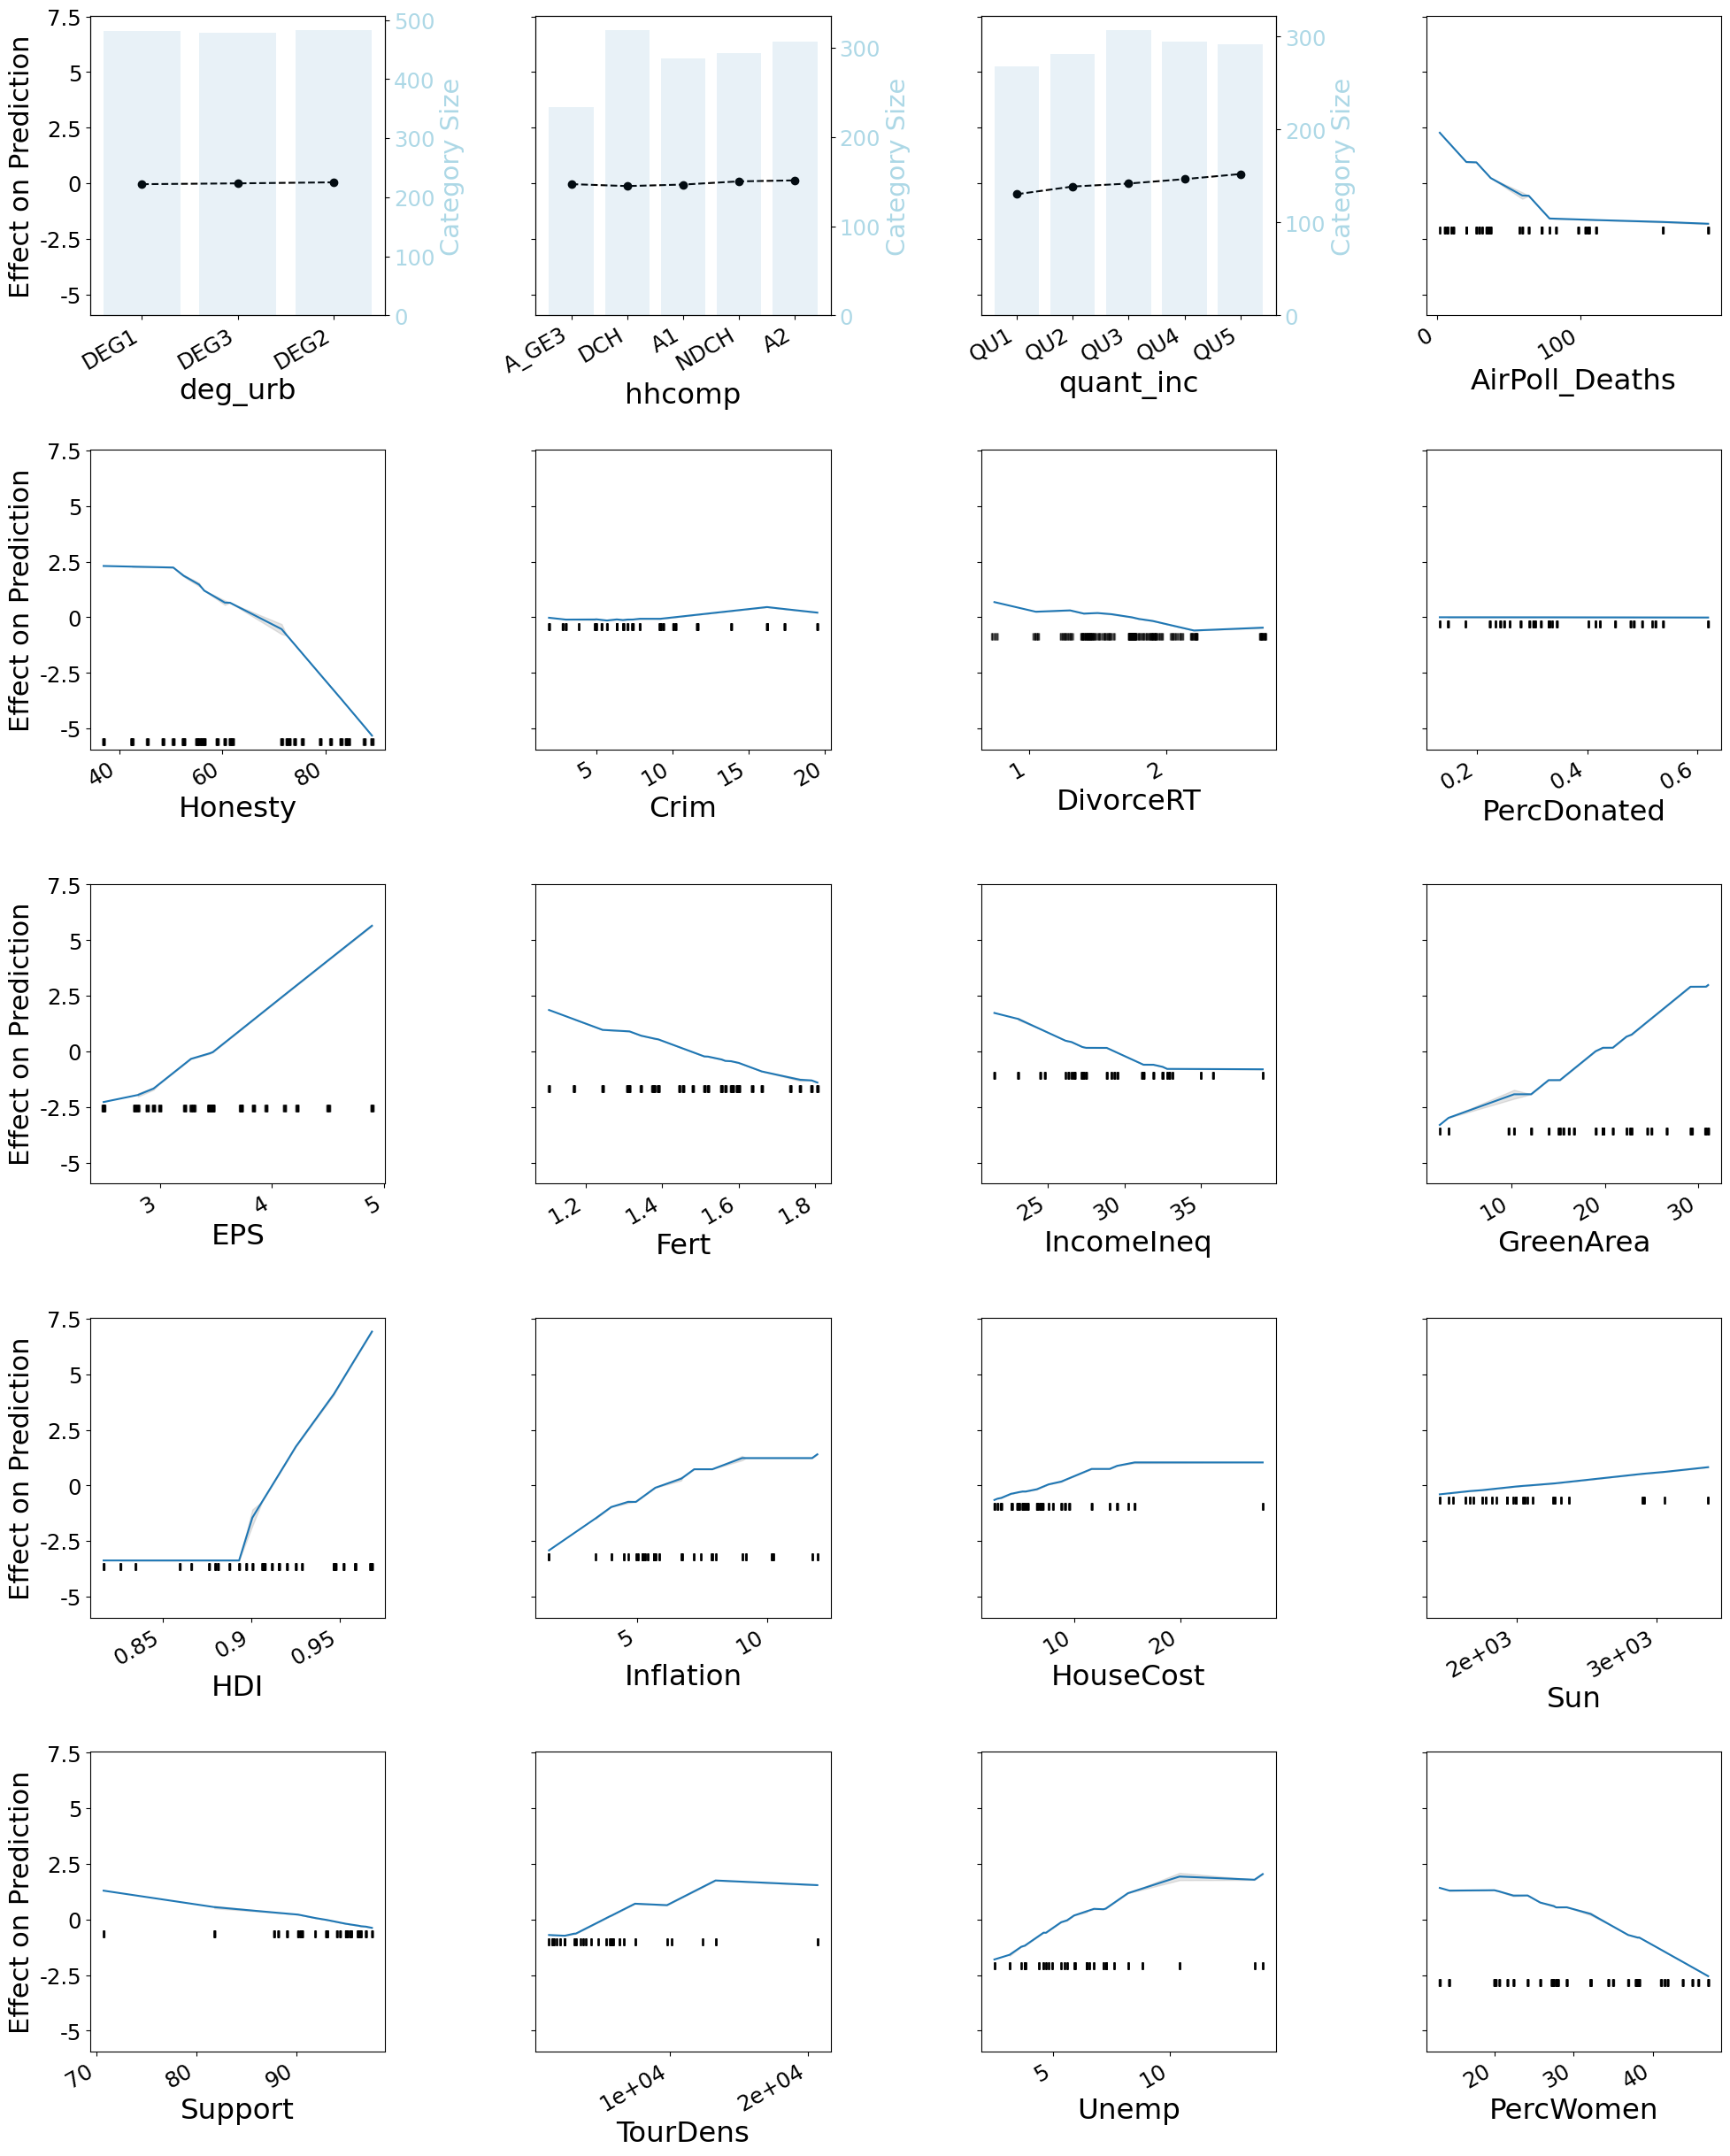

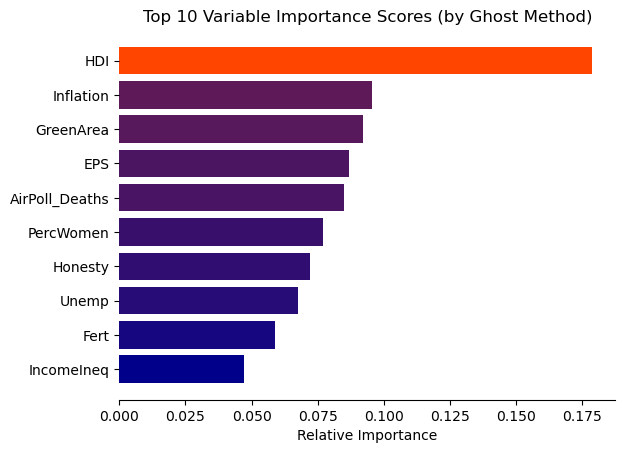

***** Comprehensive Analysis of Model Variable Importance *****
                Features with largest Kendall correlation with target
HDI                                                          0.47    
Honesty                                                      0.44    
AirPoll_Deaths                                              -0.40    
quant_inc                                                    0.34    
PercDonated                                                  0.29    
IncomeIneq                                                  -0.28    
Sun                                                         -0.27    
EPS                                                          0.26    
PercWomen                                                    0.24    
Support                                                      0.21    
Important variables in isolation but less so given the rest:
['PercDonated', 'Sun', 'Support']
(Might be strongly correlated with 1 or more covariates in the model)
I

,Importance
HDI,0.18
Inflation,0.10
GreenArea,0.09
EPS,0.09
AirPoll_Deaths,0.09
PercWomen,0.08
Honesty,0.07
Unemp,0.07
Fert,0.06
IncomeIneq,0.05


In [7]:
# (c) Show me the most important variables
model.varImp(X_test, y_test, model, corAnalysis=True, filename="LifeSat")
# this method, unlike the traditional permutation-based approach, takes into account correlations among features
# Optional: use the traditional permutation-based approach instead (will be slow, about 3 minutes)
# model.varImpPerm(X_test, y_test, model, filename="LifeSat")

Building on our previous local analysis of a single household instance, we now zoom out to gain a **global perspective** of the model. By examining variable importance and ALE plots across all instances, we can understand which features drive predictions overall and whether their effects align with our expectations.

Here are the main insights:

- The **Human Development Index (HDI)** is, by far, the single most important feature for our model. HDI is a composite indicator capturing three fundamental dimensions of human development: health (life expectancy at birth), education (mean and expected years of schooling), and income (gross national income per capita).  
- **Inflation, green area surface in cities, the Environmental Policy Stringency (EPS) index, and deaths due to air pollution** complete the top five. Notably, three of these five features are climate- or environment-related, suggesting a central role of environmental conditions in shaping life satisfaction.  
- **Household income quintile does not appear in the top 10.** While income is clearly linked to life satisfaction, its explanatory power is partly captured by correlated variables, so its exclusion would not substantially change predictions.

### Top 5 Most Important Features

| Rank | Feature | Type |
|------|---------|------|
| 1    | Human Development Index (HDI) | Demographic/Economic |
| 2    | Inflation | Economic |
| 3    | Green area surface in cities | Environmental |
| 4    | Environmental Policy Stringency (EPS) | Environmental |
| 5    | Deaths due to air pollution | Environmental |

### Global patterns revealed by ALE plots

| Feature | Expected Global Effect ✅|
|---------|--------------------------|
| Income quintile | Positive |
| Environmental Policy Stringency (EPS) | Positive |
| Green area surface in cities | Positive |
| HDI | Positive |
| Sunlight hours per year | Positive |
| Deaths by air pollution | Negative |
| Divorce rate | Negative |
| Income inequality | Negative |

- **Unexpected directions:** Inflation emerges as a highly important feature, but up to moderately high levels (around 9% annually), it is associated with *higher* life satisfaction. This counterintuitive effect likely reflects the temporal context of the dataset (2021–2022, immediately post-COVID): regions that recovered faster saw both larger improvements in life satisfaction and higher inflation, producing a positive association in our model.

## 3. Applications

Our accurate yet interpretable model lends itself to two interesting applications.

### 3.1. Estimating the Missing Life Satisfaction Score of Germany in 2022

It is unclear why the value for Germany is missing in 2022, but we can use our model to estimate it. Specifically, we will predict the **75 demographic combinations** of degree of urbanization (3), household composition (5), and income quintile (5) possible for Germany. We then take the **uniformly-weighted average** of those predictions to obtain an estimate for Germany 2022.

In [8]:
DE_star = df_complete.iloc[0,:-1] #tmp

DE_star[3] = df_AQ[df_AQ['Country'] == 'DE'].iloc[:, 1].values[0]
DE_star[4] = df_Corrupt[df_Corrupt['Country'] == 'DE'].iloc[:, 1].values[0]
DE_star[5] = df_Crim[df_Crim['Country'] == 'DE'].iloc[:, 1].values[0]
DE_star[6] = df_Div[df_Div['Country'] == 'DE'].iloc[:, 1].values[0]
DE_star[7] = 0.43 # Generosity index
DE_star[8] = df_EPS[df_EPS['Country'] == 'Germany'].iloc[:, 1].values[0]
DE_star[9] = df_Fert[df_Fert['Country'] == 'DE'].iloc[:, 1].values[0]
DE_star[10] = df_Gini[df_Gini['Country'] == 'DE'].iloc[:, 1].values[0]
DE_star[11] = df_Green[df_Green['Country'] == 'Germany'].iloc[:, 1].values[0]
DE_star[12] = df_HDI[df_HDI['Country'] == 'Germany'].iloc[:, 1].values[0]
DE_star[13] = df_HICP[df_HICP['Country'] == 'DE'].iloc[:, 1].values[0]
DE_star[14] = df_House[df_House['Country'] == 'DE'].iloc[:, 1].values[0]
DE_star[15] = df_Sun[df_Sun['Country'] == 'Germany'].iloc[:, 1].values[0]
DE_star[16] = df_Support[df_Support['Country'] == 'DE'].iloc[:, 1].values[0]
DE_star[17] = df_Tour[df_Tour['Country'] == 'DE'].iloc[:, 1].values[0]
DE_star[18] = df_Unemp[df_Unemp['Country'] == 'DE'].iloc[:, 1].values[0]
DE_star[19] = df_Women[df_Women['Country'] == 'DE'].iloc[:, 1].values[0]

deg_urbs = set(df_LS['deg_urb'])
hhcomps = set(df_LS['hhcomp'])
quant_incs = set(df_LS['quant_inc'])

DE_preds = []
DE_max = 0
DE_min = 10
for u in deg_urbs:
  for h in hhcomps:
    for i in quant_incs:
      DE_star[0] = u
      DE_star[1] = h
      DE_star[2] = i
      DE_preds.append(model.predict(DE_star))
      if DE_preds[-1] < DE_min:
        DE_min = DE_preds[-1]
        ix_min = [u,h,i]      
      if DE_preds[-1] > DE_max:
        DE_max = DE_preds[-1]
        ix_max = [u,h,i]

print(f'Lowest Predicted Life Satisfaction for Germany (2022): = {round(DE_min,2)}')
print(f'ix_min = {ix_min}')
print(f'Highest Predicted Life Satisfaction for Germany (2022): = {round(DE_max,2)}')
print(f'ix_max = {ix_max}')

for j,v in enumerate(ix_max):
  DE_star[j] = v

# How accurate are predictions at country level?
github_url = "https://raw.githubusercontent.com/adc-trust-ai/trust-free/refs/heads/main/notebooks/LifeSatData_wCountry.csv"
df_complete_wCountry = pd.read_csv(github_url)
X_wCountry = df_complete_wCountry.iloc[:,:-1]
# Make train (70%) - test (30%) split
_, X_test_wCountry, _, _ = train_test_split(X_wCountry, y, test_size=0.3, random_state=123)
# Step 1: Generate predictions for each row
X_test_wCountry.reset_index(drop=True, inplace=True)
X_test.reset_index(drop=True, inplace=True)
# The `axis=1` argument makes .apply() iterate row by row
X_test_wCountry['PredictedLifeSat'] = X_test.apply(lambda row: model.predict(row), axis=1)
# Step 2: Group by Country and calculate the average prediction
df_country_predictions = X_test_wCountry.groupby('Country')['PredictedLifeSat'].mean().reset_index()
#print(df_country_predictions) 
df_country_LS = df_complete_wCountry[['Country', 'LifeSat']]
df_country_LS = df_country_LS.groupby(['Country'])['LifeSat'].mean().reset_index()
quant95_abs_error = np.quantile(np.abs(df_country_predictions["PredictedLifeSat"].values - df_country_LS["LifeSat"].values),0.95) #0.14
print(f'Estimated Life Satisfaction for Germany (2022): {round(np.mean(DE_preds),2)} +/- {round(quant95_abs_error,2)}')

Lowest Predicted Life Satisfaction for Germany (2022): = 5.92
ix_min = ['DEG1', 'A1', 'QU1']
Highest Predicted Life Satisfaction for Germany (2022): = 7.11
ix_max = ['DEG2', 'A_GE3', 'QU5']
Estimated Life Satisfaction for Germany (2022): 6.51 +/- 0.14


**Our estimated life satisfaction for Germany in 2022 is 6.51**, with an empirical 95\% confidence interval of [6.37, 6.65]. This estimate is below the EU average in 2022 (around 7.1 as per my calculations<sup>1</sup>) and substantially below the Eurostat table values for Germany in 2020 (7.9) and 2021 (7.9). Eurostat's overall figures are on average about 0.7 higher than what we obtain with a simple average. Adjusting for their reporting methodology might bring Germany's 2022 life satisfaction estimate closer to 7.21. In any case, there is likely a significant drop from 2021 to 2022.

But not all is lost for Germany. Read on to find out how Germany's life satisfaction (at least in 2022) could not only surpass the EU's average but even the European country leading the life satisfaction charts in 2022: Switzerland (8.6).

<sup>1</sup>My calculations agree with [this Eurostat page](https://ec.europa.eu/eurostat/statistics-explained/index.php?title=Living_conditions_in_Europe_-_life_satisfaction_and_quality_of_life#Perceived_satisfaction_generally_increases_with_educational_attainment_level), which appears to contradict the table [here](https://ec.europa.eu/eurostat/databrowser/view/ilc_pw02b__custom_17766003/default/table).


### 3.2. Forget Switzerland: The Surprising Policy That Could Make Germany Europe's Happiest Country

Starting from the demographic with the highest predicted life satisfaction in Germany in 2022 — **top income quintile households with 3 or more adults living in a smaller city** — we explore the easiest path to surpass Switzerland's life satisfaction.

Using the `explain` method in TRUST, we see the potential levers to close the 8.6 – 7.11 = 1.49 gap with Switzerland.

***** Selected Instance Prediction Explanation *****
Observed feature values (unstandardized):
deg_urb              DEG2
hhcomp              A_GE3
quant_inc             QU5
AirPoll_Deaths       39.0
Honesty              79.5
Crim                 9.45
DivorceRT             1.7
PercDonated          0.43
EPS                  3.47
Fert                 1.52
IncomeIneq           30.1
GreenArea           20.84
HDI                  0.96
Inflation            5.95
HouseCost           11.45
Sun               1686.13
Support              79.8
TourDens          4005.27
Unemp                3.35
PercWomen            34.8

Categorical variables: ['deg_urb', 'hhcomp', 'quant_inc']

Feature values of the training instance with the largest predicted response:
deg_urb              DEG2
hhcomp                 A2
quant_inc             QU5
AirPoll_Deaths       20.5
Honesty              83.0
Crim                 7.85
DivorceRT             1.9
PercDonated          0.42
EPS                   4.5
Fert          

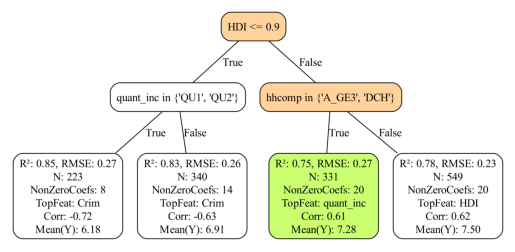

Estimated linear model coefficients (OLS):
                Estimate  Std. Error  t value       P(>|t|) Signif.
[Intercept]       -20.49       22.19    -0.92  3.565538e-01        
deg_urb             2.07        0.43     4.78  2.741741e-06     ***
hhcomp            -12.39        2.68    -4.62  5.730195e-06     ***
quant_inc           0.87        0.05    17.91  9.257530e-50     ***
AirPoll_Deaths     -0.06        0.01    -4.84  2.017350e-06     ***
Honesty            -0.25        0.04    -5.49  8.406977e-08     ***
Crim                0.07        0.02     2.99  3.040940e-03      **
DivorceRT          -1.52        0.21    -7.36  1.669174e-12     ***
(PercDonated)       0.01        0.33     0.04  9.681807e-01        
EPS                 3.81        0.58     6.53  2.753639e-10     ***
Fert               -6.40        1.09    -5.89  9.881864e-09     ***
IncomeIneq         -0.30        0.07    -4.49  1.000537e-05     ***
GreenArea           0.33        0.05     7.00  1.623140e-11     ***
HDI  

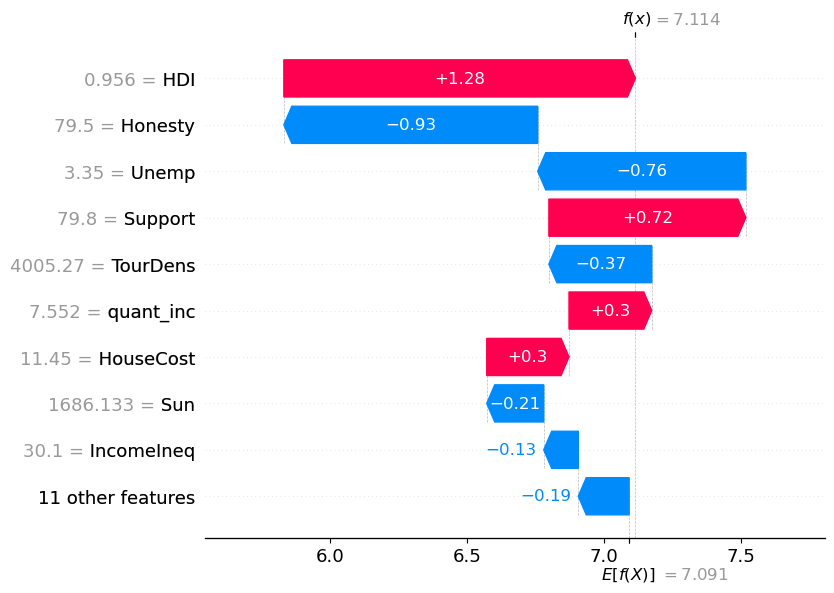

 prediction  avg pred.  HDI  Honesty  Unemp  Support  TourDens  quant_inc  HouseCost   Sun  IncomeIneq  Others
       7.11       7.09 1.28    -0.93  -0.76     0.72     -0.37        0.3        0.3 -0.21       -0.13   -0.19

--- Terminal node metrics ---
RMSE: 0.27. Adj. R²: 0.73. F-stat: 45.99, p-value: 1.11e-16.
Predicted LifeSat value: 7.11
Average LifeSat value in leaf: 7.28

<<< Summary >>>
-The predicted value of 7.11 (medium) is mainly due to deg_urb being DEG2, hhcomp being A_GE3, quant_inc being QU5, large values of Honesty, Crim, EPS, GreenArea, HDI and HouseCost, intermediate values of AirPoll_Deaths, Fert, IncomeIneq, Inflation, TourDens and PercWomen, small values of DivorceRT and Sun, and very small values of Support and Unemp. Note: although this configuration yielded a medium predicted value, it is not necessarily the only configuration capable of doing so.
-Compared to the training instance with largest predicted response, this instance has the same deg_urb, hhcomp A_GE3

In [9]:
model.explain(DE_star, filename="LifeSat_DE_max")

The estimated linear model coefficients for this demographic group indicate that the "simplest" way would be to **increase Germany's HDI from 0.956 to 0.9681** (+0.0121 = 1.49/123.56). However, this would require Germany to become Europe's leader in HDI, moving from 6th to 1st position, surpassing Switzerland (0.967) and Norway (0.968).  

Although a 0.0121 HDI increase seems small, it is extremely challenging (if not impossible) for a highly developed country like Germany to achieve. We are, of course, simplifying the analysis (*a lot*) and assuming ceteris paribus.

A more feasible option is to **raise Germany's Environmental Policy Stringency (EPS) Index**. In 2022, Germany's EPS index was 3.472, just above Europe's median of 3.458. Switzerland's EPS index was 4.5, over 1 point higher than Germany's. Therefore, **by increasing Germany's EPS by 0.391 (from 3.472 to 3.863), at least one demographic group could surpass Switzerland's average life satisfaction**.  

Moreover, **by matching Switzerland's EPS index, *all* demographic groups in Germany would achieve a higher life satisfaction than Switzerland!**.  

Of course, this simplified analysis ignores correlations between EPS and other features — it may not be possible to adjust EPS independently. In addition, as we know, correlation does not imply causation. Nevertheless, it provides a starting point for potentially impactful policy-making, which would have been impossible to uncover with a black-box model.  

Indeed, **these insights demonstrate why exceptional accuracy combined with top-tier interpretability — exactly what trust-free delivers — can produce actionable recommendations**. Germany’s life satisfaction in 2022 could not only surpass the EU average but also exceed the European leader, Switzerland (8.6), in certain scenarios.

## 4. Bonus: Comparing with Random Forest, Decision Tree and Lasso Regression

As a bonus, let's examine what other popular ML models have to offer.

### 4.1. Random Forest

Random Forest is an ensemble model that combines the predictions of hundreds of decision trees to deliver very accurate results. However, it is by construction a black box: it is generally impossible to know the global structure of the model or the precise reason behind a specific prediction.


First 5 predictions: [7.402 6.744 7.446 7.06  6.51 ]
First 5 true y values in test set: [7.4   7.067 7.333 6.7   6.333]
Test R^2: 0.853
Average tree depth = 19.132
Average number of leaves per tree = 883.138
Number of trees = 500
About 441569 leaves in total, i.e. nearly half a million!


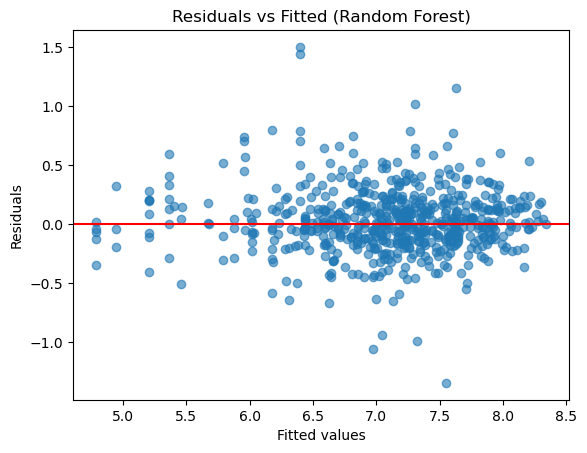

In [10]:
def one_hot(df, cols):
  """
  @param df pandas DataFrame
  @param cols a list with string names of columns to encode 
  @return a DataFrame with one-hot encoding
  """
  for each in cols:
    dummies = pd.get_dummies(df[each], prefix=each, drop_first=True, dtype=int) #drops 1st level
    df = pd.concat([df, dummies], axis=1)
    df = df.drop(each,axis=1)
  return df

X_1Hot_enc = one_hot(X, ['deg_urb', 'hhcomp','quant_inc'])
X_train_1Hot_enc, X_test_1Hot_enc, y_train, y_test = train_test_split(X_1Hot_enc, y, test_size=0.3, random_state=123)

# RF
from sklearn.ensemble import RandomForestRegressor
# RF cannot handle categorical variables natively, so we one-hot encoded them
rf = RandomForestRegressor(n_estimators=500, random_state=123)
rf.fit(X_train_1Hot_enc, y_train)
y_pred_rf = rf.predict(X_test_1Hot_enc)

print("\nFirst 5 predictions:", np.round(y_pred_rf[:5],3))
print("First 5 true y values in test set:", np.round(y_test.values[:5],3))
print("Test R^2:", round(r2_score(y_test, y_pred_rf),3)) #0.853
# essentially identical accuracy as our TRUST tree, BUT here we used 500 trees
# with depths and number of leaves as below

# Create an empty list to store the depths
tree_depths = []
tree_leaves = []

# Iterate through each tree and append its depth to the list
for tree in rf.estimators_:
  tree_depths.append(tree.get_depth())
  tree_leaves.append(tree.get_n_leaves())

print(f'Average tree depth = {np.mean(tree_depths)}') # depth 19 each tree (mean)
print(f'Average number of leaves per tree = {np.mean(tree_leaves)}') # 882 leaves each tree (mean)
print("Number of trees = 500")
print(f'About {round(500*np.mean(tree_leaves))} leaves in total, i.e. nearly half a million!')
# so nearly half a million leaves were used to barely surpass the accuracy of a TRUST tree with 4 leaves

residuals_rf = y_test - y_pred_rf
plt.clf()
plt.scatter(y_pred, residuals_rf, alpha=0.6)
plt.axhline(0, color="red")
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted (Random Forest)")
plt.show() #very similar to TRUST's

As we can see, trust-free achieves an accuracy comparable to Random Forest (0.845 vs 0.853), but using only 4 leaves instead of nearly half a million. The residual plots are essentially identical.


As we can see, trust-free achieves an accuracy comparable to Random Forest (0.845 vs 0.853), but using only 4 leaves instead of nearly half a million. The residual plots look essentially identical.

Let's look at one decision tree at a time now, to see if we can get a better accuracy-interpretability trade-off.

### 4.2. Decision Tree

Tree depth: 20
Number of leaves: 1397

First 5 predictions: [7.5   6.733 7.667 7.033 6.6  ]
First 5 true y values in test set: [7.4   7.067 7.333 6.7   6.333]
Test R^2: 0.755


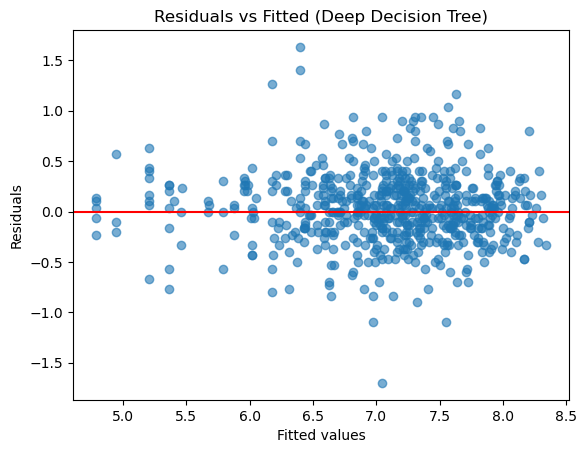


First 5 predictions: [6.996 7.629 7.629 6.996 6.996]
First 5 true y values in test set: [7.4   7.067 7.333 6.7   6.333]
Test R^2: 0.543


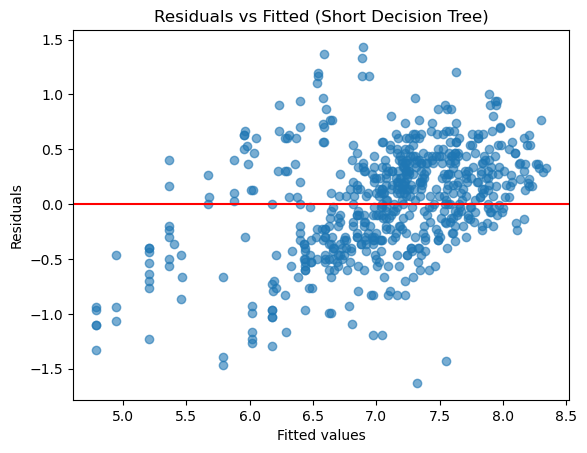

In [11]:
# Deep Decision Tree
from sklearn.tree import DecisionTreeRegressor
# DT cannot handle categorical variables natively either
ddt = DecisionTreeRegressor(random_state=123)
ddt.fit(X_train_1Hot_enc, y_train)
print(f'Tree depth: {ddt.get_depth()}') # depth 20
print(f'Number of leaves: {ddt.get_n_leaves()}') #1397 leaves
y_pred_ddt = ddt.predict(X_test_1Hot_enc)
print("\nFirst 5 predictions:", np.round(y_pred_ddt[:5],3))
print("First 5 true y values in test set:", np.round(y_test.values[:5],3))
print("Test R^2:", round(r2_score(y_test, y_pred_ddt),3)) #0.755

residuals_ddt = y_test - y_pred_ddt
plt.clf()
plt.scatter(y_pred, residuals_ddt, alpha=0.6)
plt.axhline(0, color="red")
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted (Deep Decision Tree)")
plt.show()

# Short Decision Tree
# let's try now with a maximum depth of 2, like our TRUST tree, see how it does...
sdt = DecisionTreeRegressor(max_depth=2, random_state=123)
sdt.fit(X_train_1Hot_enc, y_train)
y_pred_sdt = sdt.predict(X_test_1Hot_enc)
print("\nFirst 5 predictions:", np.round(y_pred_sdt[:5],3))
print("First 5 true y values in test set:", np.round(y_test.values[:5],3))
print("Test R^2:", round(r2_score(y_test, y_pred_sdt),3)) #0.543

residuals_sdt = y_test - y_pred_sdt
plt.clf()
plt.scatter(y_pred, residuals_sdt, alpha=0.6)
plt.axhline(0, color="red")
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted (Short Decision Tree)")
plt.show()

A very deep decision tree with nearly 1,400 leaves (essentially a black box) still cannot match the accuracy of a TRUST model with 4 leaves (test $R^2$ of 0.755 vs 0.845).

If we restrict the decision tree to the same number of leaves as our TRUST model (4), its test $R^2$ falls even further behind that of TRUST (0.543 vs 0.845). Moreover, in this case, the residual vs. fitted plot reveals violations of model assumptions, which compromises the validity of the fitted tree and renders its interpretability largely useless.

As I like to say, *"if a model does not need to be accurate, I can make it arbitrarily interpretable"* (e.g., a constant). Similarly, in many cases, we do not care how accurate a model is unless we can *trust* it (pun not intended).

Finally, let's see if a sparse linear model can achieve a better result.

### 4.3. Lasso


First 5 predictions: [7.063 7.371 6.821 7.015 6.863]
First 5 true y values in test set: [7.4   7.067 7.333 6.7   6.333]
Test R^2: 0.754
27 (out of 27) nonzero coefficients.


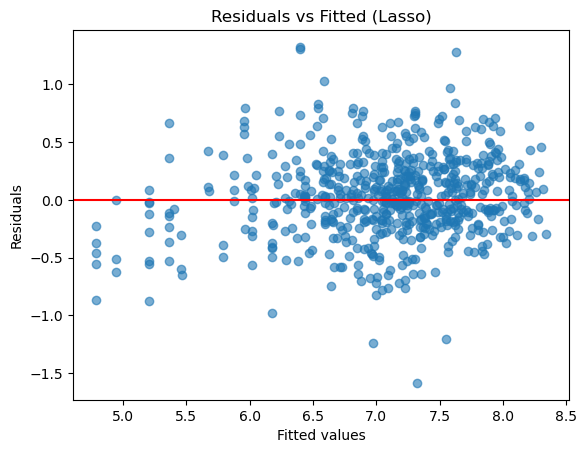

In [12]:
# Lasso
from sklearn.linear_model import LassoCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
# Lasso cannot handle categorical variables natively either, nor missing values
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='mean')
X_train_imputed = imputer.fit_transform(X_train_1Hot_enc)
X_test_imputed = imputer.transform(X_test_1Hot_enc)
# Create a pipeline that first scales the data and then fits the LassoCV model
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('lasso', LassoCV(cv=10, random_state=123))
])
pipeline.fit(X_train_imputed, y_train)
y_pred_lasso = pipeline.predict(X_test_imputed)
print("\nFirst 5 predictions:", np.round(y_pred_lasso[:5],3))
print("First 5 true y values in test set:", np.round(y_test.values[:5],3))
print("Test R^2:", round(r2_score(y_test, y_pred_lasso),3)) #0.754
# Access the Lasso model inside the pipeline
lasso_model = pipeline.named_steps['lasso']
print(f'{sum(lasso_model.coef_ != 0)} (out of {X_test_imputed.shape[1]}) nonzero coefficients.') #all 27 coefficients (recall we did 1-hot encoding) are actually nonzero!

residuals_lasso = y_test - y_pred_lasso
plt.clf()
plt.scatter(y_pred, residuals_lasso, alpha=0.6)
plt.axhline(0, color="red")
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted (Lasso)")
plt.show()


Lasso fails to capture important nonlinearities, as the residual plot shows (systematic overprediction for smaller fitted values), and its test $R^2$ is considerably lower than what can be achieved with a more flexible model such as `trust-free` (0.754 vs 0.845).

Moreover, note that this Lasso model gave a nonzero weight to all 27 features (after one-hot encoding categorical variables), while the leaves in `trust-free` have a number of nonzero coefficients ranging between 8 and 20. For a fixed instance, this can make it easier to interpret the more accurate trust-free model than the Lasso model.

### 4.4. Comparison at a Glance

Below we summarize the performance of TRUST and the alternative models. Both plots attempt to combine the accuracy and interpretability metrics of each algorithm. The first plot focuses on **global interpretability** (how easy it is to understand the overall behavior of the model), while the second focuses on **local interpretability** (how easy it is to understand a specific prediction).

A few important remarks:

1. It is not obvious **how to calculate an interpretability score** across different model types. Counting the number of fitted parameters and/or leaves can provide a reasonable measure of global interpretability. For local interpretability, we count only the fitted parameters and/or leaves involved in a specific prediction (for TRUST, this is the average number of nonzero coefficients in the leaves, weighted by leaf sample size).

2. Even with a reasonable interpretability metric, there is **no well-established formula to combine accuracy and interpretability metrics**, likely because it is highly context-dependent. We use a **Cobb-Douglas** type of function (emphasizing accuracy) to reflect how both factors are generally valued in practice. Concretely, we define the performance score as:
$$S(A,I) = A^{0.75} \times I^{0.25}$$

<Figure size 640x480 with 0 Axes>

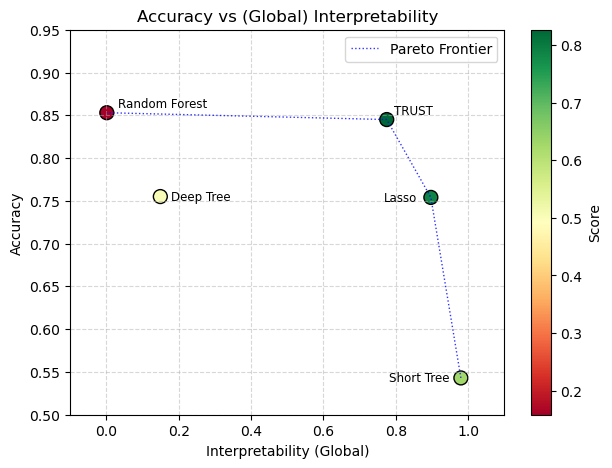

       Algorithm  Accuracy  RawComplexity  Interpretability  Score
0          TRUST     0.845             70             0.775  0.827
1  Random Forest     0.853         441569             0.001  0.158
2      Deep Tree     0.755           1397             0.149  0.503
3     Short Tree     0.543              4             0.980  0.629
4          Lasso     0.754             27             0.897  0.787


<Figure size 640x480 with 0 Axes>

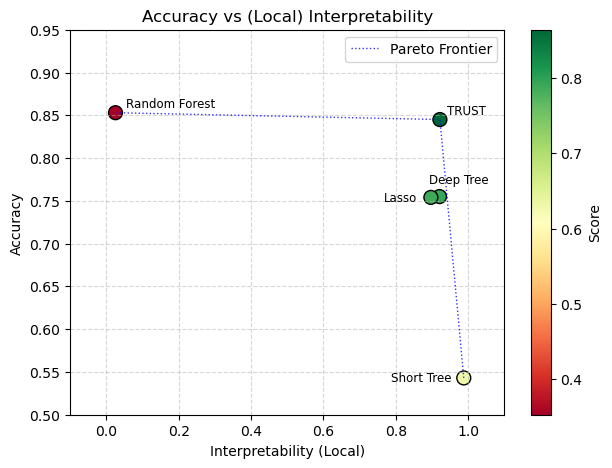

       Algorithm  Accuracy  RawComplexity  Interpretability  Score
0          TRUST     0.845          19.73             0.922  0.864
1  Random Forest     0.853        9566.00             0.025  0.353
2      Deep Tree     0.755          20.00             0.921  0.793
3     Short Tree     0.543           2.00             0.988  0.631
4          Lasso     0.754          27.00             0.897  0.787


In [13]:
import matplotlib.pyplot as plt

# Accuracy scores
accuracy = {
    "TRUST": 0.845,
    "Random Forest": 0.853,
    "Deep Tree": 0.755,
    "Short Tree": 0.543,
    "Lasso": 0.754
}

# Global interpretability
# -----------------------
# raw complexity = number of parameters / leaves
raw_complexity = {
    "TRUST": model.num_coefs_total + model.num_leaves,            
    "Random Forest": sum(tree_leaves),
    "Deep Tree": ddt.get_n_leaves(),
    "Short Tree": sdt.get_n_leaves(),
    "Lasso": sum(lasso_model.coef_ != 0)
}

# Convert to dataframe
df = pd.DataFrame({
    "Algorithm": list(raw_complexity.keys()),
    "Accuracy": [accuracy[alg] for alg in raw_complexity.keys()],
    "RawComplexity": [raw_complexity[alg] for alg in raw_complexity.keys()]
})

# Apply transformation (sigmoid of log complexity)
df["Interpretability"] = np.round(1 - (1 / (1 + np.exp(- ((np.log1p(df["RawComplexity"])) - 5.5)))), 3)
# Explanation:
# log1p = log(1 + x) smooths the range
# 1 / (1 + np.exp(-...)) is the standard logistic function mapping reals to [0,1]
# shifting by -5.5 centers the sigmoid around mid-scale
# 1 - (...) flips so that higher interpretability = closer to 1

# Compute product as a new column
df["Score"] = np.round(df["Accuracy"]**0.75 * df["Interpretability"]**0.25, 3)

# Sort by interpretability descending for frontier calculation
df_sorted = df.sort_values("Interpretability", ascending=False).reset_index(drop=True)

# Compute Pareto frontier
pareto_points = []
max_acc = -np.inf
for i, row in df_sorted.iterrows():
    if row["Accuracy"] > max_acc:
        pareto_points.append((row["Interpretability"], row["Accuracy"]))
        max_acc = row["Accuracy"]
pareto_points = np.array(pareto_points)

# Plot
plt.clf()
plt.figure(figsize=(7, 5))
sc = plt.scatter(
    df["Interpretability"],
    df["Accuracy"],
    c=df["Score"],
    cmap="RdYlGn",
    s=100,
    edgecolors="black"
)
# Label points with offsets (in data units)
for i, row in df.iterrows():
    # Default offset
    dx, dy = 0.03, 0.0  

    # Special-case tweaks to avoid overlap
    if row["Algorithm"] == "Random Forest":
        dx, dy = 0.03, 0.01
    elif row["Algorithm"] == "TRUST":
        dx, dy = 0.02, 0.01
    elif row["Algorithm"] == "Lasso":
        dx, dy = -0.13, 0.0
    elif row["Algorithm"] == "Short Tree":
        dx, dy = -0.2, 0.0

    plt.annotate(
        row["Algorithm"],
        (row["Interpretability"], row["Accuracy"]),     
        xytext=(row["Interpretability"] + dx,
                row["Accuracy"] + dy),                
        textcoords="data",                                  
        fontsize=8.5, va="center", ha="left"
    )

# Plot Pareto frontier
plt.plot(pareto_points[:,0], pareto_points[:,1],
         color="blue", linestyle=":", alpha=0.8, linewidth=1, label="Pareto Frontier")

plt.xlim(-0.1, 1.1)
plt.ylim(0.5, 0.95)
plt.xlabel("Interpretability (Global)")
plt.ylabel("Accuracy")
plt.title("Accuracy vs (Global) Interpretability")
plt.colorbar(sc, label="Score")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()
print(df)

# Local interpretability
# ----------------------
# raw complexity = number of parameters / leaves used to make a specific prediction

TRUST_avg_num_coefs = model.tree_depth + (223/1443)*9 + (340/1443)*15 + (331/1443)*21 + (549/1443)*21
raw_complexity_local = {
    "TRUST": round(TRUST_avg_num_coefs,2),            
    "Random Forest": sum(tree_depths),
    "Deep Tree": ddt.get_depth(),
    "Short Tree": sdt.get_depth(),
    "Lasso": sum(lasso_model.coef_ != 0)
}

# Convert to dataframe
df = pd.DataFrame({
    "Algorithm": list(raw_complexity.keys()),
    "Accuracy": [accuracy[alg] for alg in raw_complexity.keys()],
    "RawComplexity": [raw_complexity_local[alg] for alg in raw_complexity.keys()]
})

# Apply transformation (sigmoid of log complexity)
df["Interpretability"] = np.round(1 - (1 / (1 + np.exp(- ((np.log1p(df["RawComplexity"])) - 5.5)))), 3)
# Explanation:
# log1p = log(1 + x) smooths the range
# 1 / (1 + np.exp(-...)) is the standard logistic function mapping reals to [0,1]
# shifting by -5.5 centers the sigmoid around mid-scale
# 1 - (...) flips so that higher interpretability = closer to 1

# Compute product as a new column
df["Score"] = np.round(df["Accuracy"]**0.75 * df["Interpretability"]**0.25, 3)

# Sort by interpretability descending for frontier calculation
df_sorted = df.sort_values("Interpretability", ascending=False).reset_index(drop=True)

# Compute Pareto frontier
pareto_points = []
max_acc = -np.inf
for i, row in df_sorted.iterrows():
    if row["Accuracy"] > max_acc:
        pareto_points.append((row["Interpretability"], row["Accuracy"]))
        max_acc = row["Accuracy"]
pareto_points = np.array(pareto_points)

# Plot
plt.clf()
plt.figure(figsize=(7, 5))
sc = plt.scatter(
    df["Interpretability"],
    df["Accuracy"],
    c=df["Score"],
    cmap="RdYlGn",
    s=100,
    edgecolors="black"
)
# Label points with offsets (in data units)
for i, row in df.iterrows():
 
    # Special-case tweaks to avoid overlap
    if row["Algorithm"] == "Random Forest":
        dx, dy = 0.03, 0.01
    elif row["Algorithm"] == "TRUST":
        dx, dy = 0.02, 0.01
    elif row["Algorithm"] == "Deep Tree":
        dx, dy = -0.03, 0.02
    elif row["Algorithm"] == "Lasso":
        dx, dy = -0.13, 0.0
    elif row["Algorithm"] == "Short Tree":
        dx, dy = -0.2, 0.0

    plt.annotate(
        row["Algorithm"],
        (row["Interpretability"], row["Accuracy"]),     
        xytext=(row["Interpretability"] + dx,
                row["Accuracy"] + dy),                
        textcoords="data",                                  
        fontsize=8.5, va="center", ha="left"
    )

# Plot Pareto frontier
plt.plot(pareto_points[:,0], pareto_points[:,1],
         color="blue", linestyle=":", alpha=0.8, linewidth=1, label="Pareto Frontier")

plt.xlim(-0.1, 1.1)
plt.ylim(0.5, 0.95)
plt.xlabel("Interpretability (Local)")
plt.ylabel("Accuracy")
plt.title("Accuracy vs (Local) Interpretability")
plt.colorbar(sc, label="Score")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()
print(df)

Overall, `trust-free` achieves the best accuracy-interpretability combination, both globally and, especially, locally: an accuracy on par with Random Forest, with interpretability comparable to short decision trees and sparse linear models. All while natively handling missing values and categorical features, unlike the other popular scikit-learn models tested.

For a more comprehensive benchmarking including additional models and 60 datasets, see the [TRUST preprint](https://arxiv.org/abs/2506.15791).

# Congrats, you've made it to the end! 🎉

We hope this tutorial was useful. Now, with the **trust-free** package under your belt, you’ll be ready to tackle with confidence any regression problem thrown your way!

Your feedback helps us improve ❤️ Please share your comments, questions, or suggestions here: [2-minute Feedback Form](https://docs.google.com/forms/d/1a02AW5dRy6HJj5WhQKWfLUptCQnT_WfSnUrLb7Jq2C0/edit).

👉 Want to go further? Check out our [Project page](https://adc-trust-ai.github.io/trust/) and our [GitHub repository](https://github.com/adc-trust-ai/trust-free) to stay up to date with the latest releases.


### Session info 

In [14]:
import sys, platform, sklearn, matplotlib, openpyxl, lxml

print("Python:", sys.version)
print("OS:", platform.platform())
print("trust-free: 1.1.1")
print("pandas:", pd.__version__)
print("numpy:", np.__version__)
print("scikit-learn:", sklearn.__version__)
print("matplotlib:", matplotlib.__version__)
print("eurostat: 1.1.1")
print("openpyxl:", openpyxl.__version__)
print("lxml:", lxml.__version__)

Python: 3.11.13 | packaged by conda-forge | (main, Jun  4 2025, 14:52:34) [Clang 18.1.8 ]
OS: macOS-15.6.1-arm64-arm-64bit
trust-free: 1.1.1
pandas: 2.3.2
numpy: 1.26.4
scikit-learn: 1.7.1
matplotlib: 3.10.5
eurostat: 1.1.1
openpyxl: 3.1.5
lxml: 6.0.1
